<a href="https://colab.research.google.com/github/TheQuantSarah/tail-risk-var-analysis/blob/main/var_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

In [ ]:
tickers = ["BTC-USD", "GLD", "SPY"]

prices = yf.download(
    tickers,
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  3 of 3 completed


Ticker,BTC-USD,GLD,SPY
Date,,,
2020-01-01,7200.174316,NaN,NaN
2020-01-02,6985.470215,143.949997,296.125244
2020-01-03,7344.884277,145.860001,293.882874
2020-01-04,7410.656738,NaN,NaN
2020-01-05,7411.317383,NaN,NaN


In [ ]:
common_prices = prices.dropna()

common_prices.head()

Ticker,BTC-USD,GLD,SPY
Date,,,
2020-01-02,6985.470215,143.949997,296.125244
2020-01-03,7344.884277,145.860001,293.882874
2020-01-06,7769.219238,147.389999,295.004181
2020-01-07,8163.692383,147.970001,294.174683
2020-01-08,8079.862793,146.860001,295.742554


In [ ]:
print("Original data:", prices.shape)
print("Common trading days:", common_prices.shape)

Original data: (2192, 3)
Common trading days: (1508, 3)


In [ ]:
log_returns = np.log(common_prices / common_prices.shift(1))

log_returns.head()

Ticker,BTC-USD,GLD,SPY
Date,,,
2020-01-02,NaN,NaN,NaN
2020-01-03,0.050172,0.013181,-0.007601
2020-01-06,0.056166,0.010435,0.003808
2020-01-07,0.049527,0.003927,-0.002816
2020-01-08,-0.010322,-0.007530,0.005316


In [ ]:
log_returns = log_returns.dropna()

log_returns.head()

Ticker,BTC-USD,GLD,SPY
Date,,,
2020-01-03,0.050172,0.013181,-0.007601
2020-01-06,0.056166,0.010435,0.003808
2020-01-07,0.049527,0.003927,-0.002816
2020-01-08,-0.010322,-0.007530,0.005316
2020-01-09,-0.025165,-0.005668,0.006757


In [ ]:
summary_stats = pd.DataFrame({
    "Mean": log_returns.mean(),
    "Std Dev": log_returns.std(),
    "Skewness": log_returns.skew(),
    "Kurtosis": log_returns.kurt()
})

summary_stats

,Mean,Std Dev,Skewness,Kurtosis
Ticker,,,,
BTC-USD,0.001677,0.039265,-1.222821,16.350805
GLD,0.000672,0.010309,-0.433609,3.189463
SPY,0.000550,0.013101,-0.558939,13.437538


In [ ]:
import matplotlib.pyplot as plt

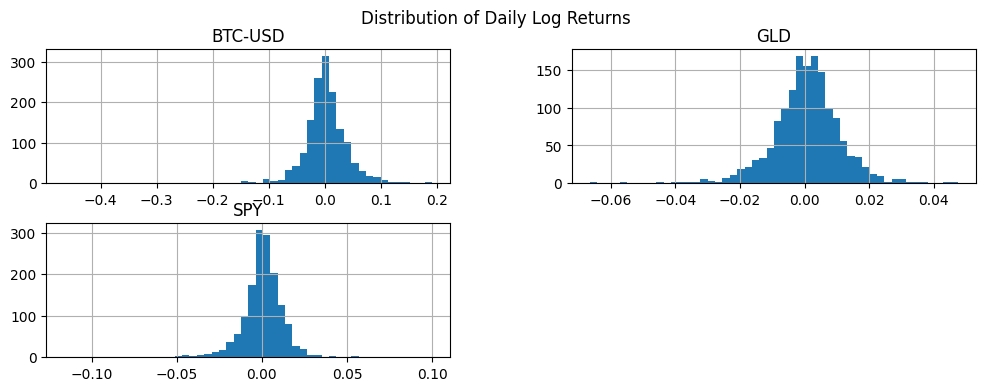

In [ ]:
log_returns.hist(bins=50, figsize=(12, 4))

plt.suptitle("Distribution of Daily Log Returns")
plt.show()

In [ ]:
from scipy.stats import norm

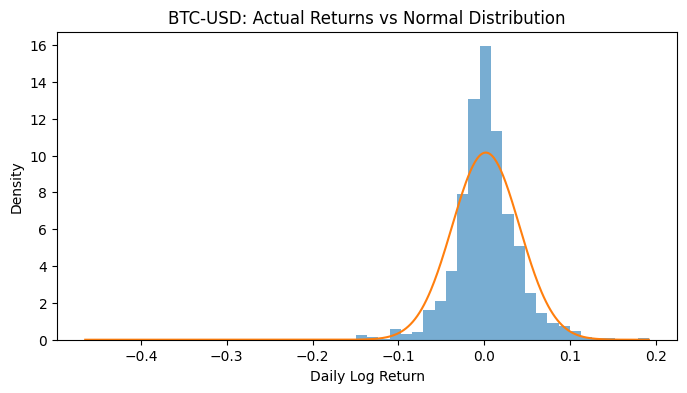

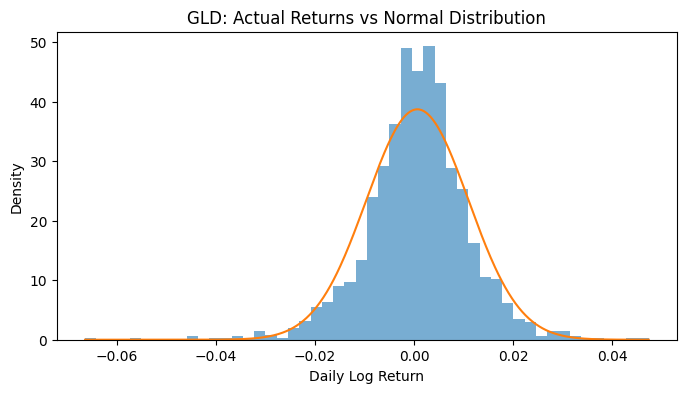

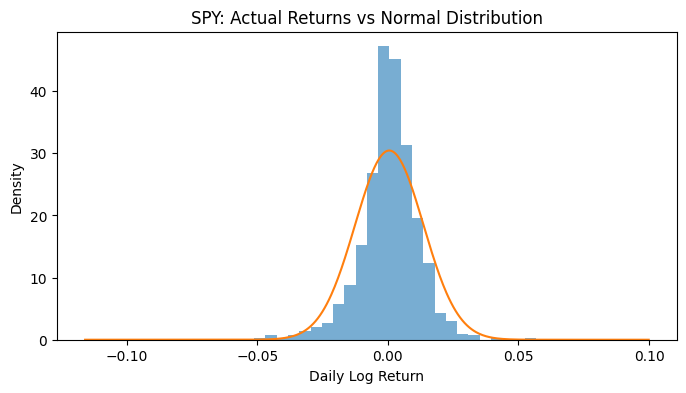

In [ ]:
for asset in log_returns.columns:
    data = log_returns[asset]

    mean = data.mean()
    std = data.std()

    x = np.linspace(data.min(), data.max(), 500)

    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=50, density=True, alpha=0.6)
    plt.plot(x, norm.pdf(x, mean, std))

    plt.title(f"{asset}: Actual Returns vs Normal Distribution")
    plt.xlabel("Daily Log Return")
    plt.ylabel("Density")
    plt.show()

In [ ]:
  norm.pdf(x, mean, std)

array([2.13822163e-16, 2.86555575e-16, 3.83611799e-16, 5.12981856e-16,
       6.85234161e-16, 9.14329979e-16, 1.21869174e-15, 1.62260095e-15,
       2.15802533e-15, 2.86700403e-15, 3.80475785e-15, 5.04374003e-15,
       6.67890579e-15, 8.83455939e-15, 1.16732403e-14, 1.54072421e-14,
       2.03135274e-14, 2.67530149e-14, 3.51954947e-14, 4.62517712e-14,
       6.07150861e-14, 7.96144347e-14, 1.04283109e-13, 1.36446712e-13,
       1.78336046e-13, 2.32831720e-13, 3.03649179e-13, 3.95575175e-13,
       5.14769609e-13, 6.69150370e-13, 8.68883398e-13, 1.12700600e-12,
       1.46021872e-12, 1.88989008e-12, 2.44333003e-12, 3.15540184e-12,
       4.07056007e-12, 5.24542419e-12, 6.75202458e-12, 8.68189176e-12,
       1.11512017e-11, 1.43072423e-11, 1.83365295e-11, 2.34749841e-11,
       3.00206730e-11, 3.83497461e-11, 4.89363435e-11, 6.23774321e-11,
       7.94237559e-11, 1.01018357e-10, 1.28344463e-10, 1.62884937e-10,
       2.06496010e-10, 2.61498593e-10, 3.30791242e-10, 4.17989721e-10,
      